# Fit plotter

In [1]:
%run pylib/tools dark
from utilities.ipynb_docgen import show
from importlib import reload
from like3 import views
reload(views)


<module 'like3.views' from '/mnt/c/users/thbur/onedrive/work/kerr-diffuse/like3/views.py'>

In [2]:
def fit_plot( func, fprime, x0, 
             *,ax=None, bounds=(-5,5), nolabels=False , y2lim=(-5,5), **kwargs):
    """make a plot showing the log likelihood and its derivative as a function of
    expected sigma, evaluated from the second derivative at the current point
   
    Parameters
    ----------
    func : callable
        function to evaluate log likelihood
    fprime : callable
        function to evaluate derivative of log likelihood
    x0 : float
        initial position to evaluate log likelihood and derivative
    ax : matplotlib.axes.Axes, optional
        axis to plot on, by default None
    nolabels : bool, optional
        if True, do not add axis labels, by default False
    y2lim : tuple, optional
        y-axis limits for derivative plot, by default (-5,5)
    """
    import matplotlib.pyplot as plt
    from scipy import optimize
 

    # find root and hessian (second derivative)
    sol = optimize.root(fprime, x0)# method='linearmixing')
    assert sol.success
    mu, sigma = sol.x[0], 1/np.sqrt(sol.r[0]) # Normal approximation: mu and sigma
    ref = func(mu)

    fig, ax = plt.subplots( figsize=(5,4)) if ax is None else (ax.figure, ax)
   
    xsig = np.linspace(-3, 3, 27)
    x =  mu + xsig * sigma 
    ax.plot(xsig, np.array(list(map(func,x)))-ref, '-b') # plot of log likelihood
    ax.plot(xsig, -0.5*((xsig)/sigma)**2, '--b') # plot of expected likelihood shape

    ax.set( ylim=(-5,0.5), xlim=(-4,4))
    ax.axvline(0, color='grey', ls = ':')
    ax.axhline(0, color='grey', ls = ':')
    ax.plot([-1,1], [-0.5,-0.5], '|-w')
    ax.set_xticks([-2,0,2])
    ax.grid(False)
    ax.text( 0,-4, rf'{mu:9.3f} $\pm$ {sigma:5.3f}', size=12, ha='center', backgroundcolor='k' )   
    ax.set(**kwargs)
    if not np.isnan(sigma):
        ax2 = ax.twinx()
        gradvals = -sigma*np.array(list(map(fprime, x)))
        ax2.plot(xsig, gradvals, '-r')
        ax2.axhline(0, color='r', ls=':')
        ax2.set_ylim( y2lim)
        if not nolabels: 
            ax.set_ylabel('log likelihood', fontsize=14)
            ax2.set_ylabel(r'derivative ($\sigma$ units)', fontsize=14)
            ax.set_xlabel(r'value ($\sigma$ units)', fontsize=14)
        else: ax2.set_yticklabels([])
        ax2.grid(False)
    return fig


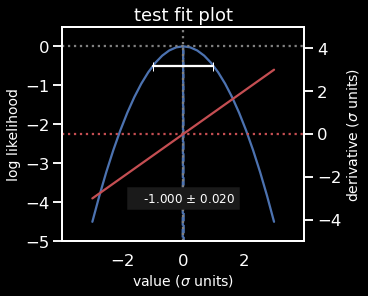

In [3]:
mu, sig = -1, 2e-2
func, fprime, x0= (
    lambda x: -(x-mu)**2/(2*sig**2),
    lambda x: -(x-mu)/sig**2,
    0
)

views.fit_plot(
    func,
    fprime,
    0,
    title='test fit plot',
)
plt.show()


In [ ]:
from scipy import optimize
sol = optimize.root(fprime, mu+1,)# method='linearmixing')
assert sol.success
mu, sig = sol.x[0], 1/np.sqrt(sol.r[0])
mu, sig

In [78]:
sol.fjac

array([[-1.]])

In [69]:
optimize.root(fprime, 3)

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00]
       x: [-1.000e+00]
  method: hybr
    nfev: 6
    fjac: [[-1.000e+00]]
       r: [-1.000e+04]
     qtf: [ 8.725e-08]

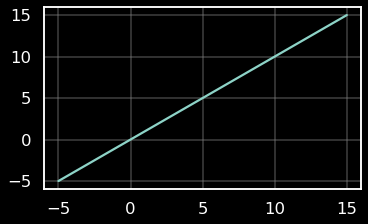

In [61]:
plt.plot((x:=np.linspace(-5,15,100)), [fprime(x) for x in x])

In [62]:
fprime(0)

0.0